In [16]:
import os
import sys
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from project_territory_map import read_vtu_file
sys.path.append(os.path.pardir)
from utilities import ThresholdInBetween
from vtk.util.numpy_support import vtk_to_numpy

In [7]:
pre_CABG_MBF = read_vtu_file("/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu")
post_CABG_MBF = read_vtu_file("/Volumes/T7_Research/CABG/05_PrePostCABG/Validate_Registeration/re-registered/SU03B_projected.vtu")
registered_mbf_map = read_vtu_file("/Volumes/T7_Research/CABG/05_PrePostCABG/Validate_Registeration/registered/SU03B_Registered.vtu")
label_file = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories_Labels.dat"

In [10]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
    
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            

    return AbsMBFData

In [9]:
print(pre_CABG_MBF)

vtkUnstructuredGrid (0x32b66cbb0)
  Debug: Off
  Modified Time: 1081
  Reference Count: 1
  Registered Events: (none)
  Information: 0x31b1ba840
  Data Released: False
  Global Release Data: Off
  UpdateTime: 2100
  Field Data:
    Debug: Off
    Modified Time: 1019
    Reference Count: 1
    Registered Events: (none)
    Number Of Arrays: 0
    Number Of Components: 0
    Number Of Tuples: 0
  Number Of Points: 517892
  Number Of Cells: 438496
  Cell Data:
    Debug: Off
    Modified Time: 1028
    Reference Count: 1
    Registered Events: 
      Registered Observers:
        vtkObserver (0x32b66f430)
          Event: 33
          EventName: ModifiedEvent
          Command: 0x31b1ba8d0
          Priority: 0
          Generation: 3
          Tag: 1
    Number Of Arrays: 0
    Number Of Components: 0
    Number Of Tuples: 0
    Copy Tuple Flags: ( 1 1 1 1 1 0 1 1 1 1 1 1 )
    Interpolate Flags: ( 1 1 1 1 1 0 0 1 1 1 1 0 )
    Pass Through Flags: ( 1 1 1 1 1 1 1 1 1 1 1 1 )
    Scalars:

In [13]:
tags = ["LAD", "Diag", "RCA"]
MBF_Labels = ReadLabels(label_file, tags)
pre_AbsMBFData = CollectMBFData(pre_CABG_MBF, MBF_Labels)
post_AbsMBFData = CollectMBFData(post_CABG_MBF, MBF_Labels)
registered_AbsMBFData = CollectMBFData(registered_mbf_map, MBF_Labels)


In [15]:
pre_AbsMBFData

{'LAD': array([115., 116., 116., ..., 111.,  92., 102.], shape=(109486,)),
 'Diag': array([39., 40., 36., ..., 63., 66., 63.], shape=(136520,)),
 'RCA': array([111., 107., 102., ..., 113., 108., 113.], shape=(110997,)),
 'Non-grafted\nstenosis>50%': array([ 56.,  63.,  70., ...,  96., 108., 108.], shape=(34004,)),
 'Non-grafted\nstenosis<50%': array([ 73.,  79.,  82., ..., 120., 120., 120.], shape=(118128,))}

In [18]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([pre_AbsMBFData[key] for key in pre_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] * len(pre_AbsMBFData[key]) for key in pre_AbsMBFData.keys()]),
    'Condition': 'Pre-CABG'
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([post_AbsMBFData[key] for key in post_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] * len(post_AbsMBFData[key]) for key in post_AbsMBFData.keys()]),
    'Condition': 'Post-CABG'
})

df_C = pd.DataFrame({
    'MBF': np.concatenate([registered_AbsMBFData[key] for key in registered_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] * len(registered_AbsMBFData[key]) for key in registered_AbsMBFData.keys()]),
    'Condition': 'Registered'
})

df_long = pd.concat([df_A, df_B, df_C], ignore_index=True)

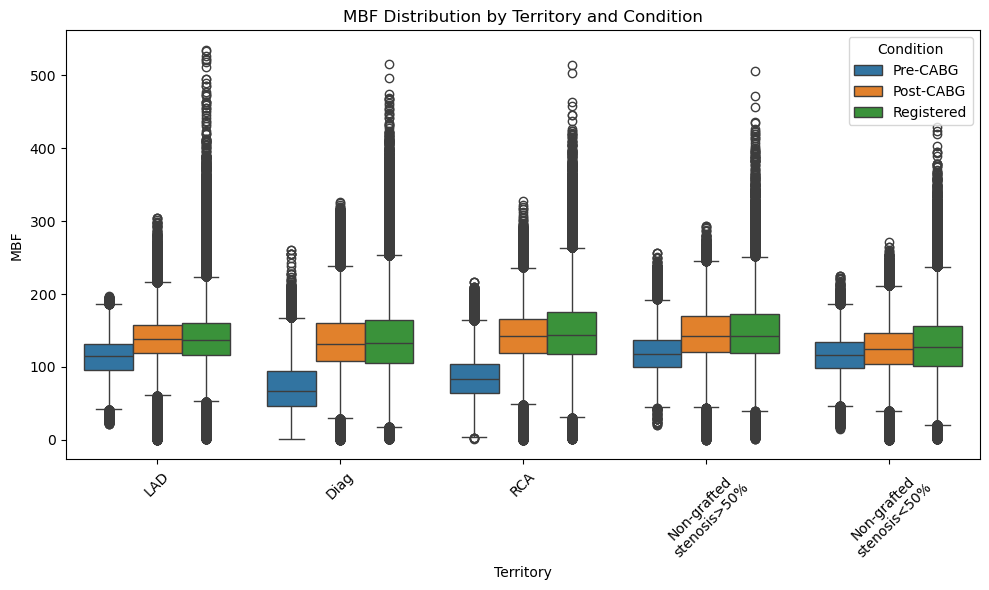

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_long, x='Territory', y='MBF', hue='Condition', ax=ax)
ax.set_title('MBF Distribution by Territory and Condition')
ax.set_xlabel('Territory')
ax.set_ylabel('MBF')
plt.xticks(rotation=45)
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


In [35]:
df_A = pd.DataFrame({
    'Mean': np.array([np.mean(pre_AbsMBFData[key]) for key in pre_AbsMBFData.keys()]),
    'Median': np.array([np.median(pre_AbsMBFData[key]) for key in pre_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] for key in pre_AbsMBFData.keys()]),
    'Condition': 'Pre-CABG'
})

df_B = pd.DataFrame({
    'Mean': np.array([np.mean(post_AbsMBFData[key]) for key in post_AbsMBFData.keys()]),
    'Median': np.array([np.median(post_AbsMBFData[key]) for key in post_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] for key in post_AbsMBFData.keys()]),
    'Condition': 'Post-CABG'
})

df_C = pd.DataFrame({
    'Mean': np.array([np.mean(registered_AbsMBFData[key]) for key in registered_AbsMBFData.keys()]),
    'Median': np.array([np.median(registered_AbsMBFData[key]) for key in registered_AbsMBFData.keys()]),
    'Territory': np.concatenate([[key] for key in registered_AbsMBFData.keys()]),
    'Condition': 'Registered'
})

df_long = pd.concat([df_A, df_B, df_C], ignore_index=True)

/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_74871/1624654857.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_long, y='Territory', x='Median', hue='Condition', ax=ax, dodge=True, join=False)


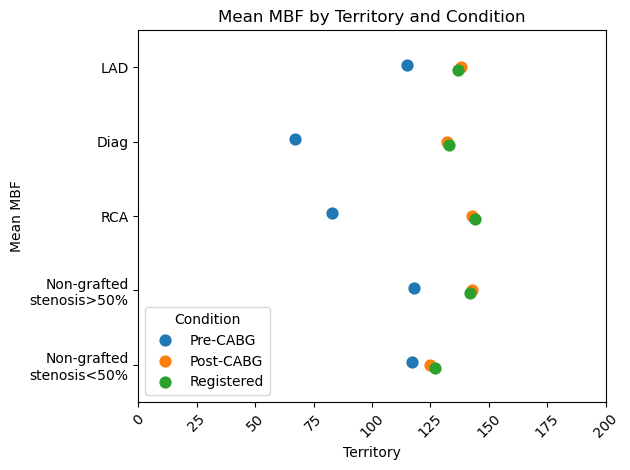

In [ ]:
fig, ax = plt.subplots()
sns.pointplot(data=df_long, y='Territory', x='Median', hue='Condition', ax=ax, dodge=True, join=False)
ax.set_title('Median MBF by Territory and Condition')
ax.set_xlabel('Territory')
ax.set_ylabel('Mean MBF')
plt.xticks(rotation=45)
plt.legend(title='Condition', loc='lower left')
plt.xlim(0, 200)
plt.tight_layout()